---
### Purpose of this Notebook:
1. **Environment Setup:** Install `ultralytics` library.
2. **Data Configuration:** Generate `data.yaml` dynamically using the splits generated in Notebook 1.
3. **Model Training:** Train three real-time CNN detectors (YOLOv10, YOLOv12, YOLOv26) for at least 50 epochs each.
4. **Visualizations & Metrics:** Log and plot training curves (Losses, mAP@50, mAP@50:95) for all three variants.
5. **Save Best Checkpoints:** Record best weight paths for the final comparative notebook.
6. **Summary Table:** Performance comparison table (parameters, training time, val metrics).


## 1. CONFIGURATION CELL
Configure hyperparameter setups here. Ensure training epochs are at least 50.


In [1]:
# ================= CONFIGURATION CELL =================
KAGGLE_ENVIRONMENT = True  # Toggle this to False if running locally

# Define dataset split paths
if KAGGLE_ENVIRONMENT:
    OUTPUT_DIR = '/kaggle/input/datasets/mdnahidulislam01/senticar-dataset-yolo-od'
else:
    OUTPUT_DIR = './SentiCAR_dataset_yolo_OD'

# Training Hyperparameters
EPOCHS = 50
BATCH_SIZE = 16
IMG_SIZE = 640
OPTIMIZER = 'AdamW'
INITIAL_LR = 0.001
DEVICE = '0'  # GPU Device (0) or 'cpu'

print('YOLO training hyperparameters configured.')


YOLO training hyperparameters configured.


## 2. ENVIRONMENT SETUP & data.yaml GENERATION
We install the `ultralytics` package and write a `data.yaml` file dynamically so YOLO training can read the split directories.


In [2]:
# Install ultralytics library
!pip install -q ultralytics

import yaml
import os
from ultralytics import YOLO

# Create data.yaml content
data_yaml = {
    'path': OUTPUT_DIR,
    'train': 'train/images',
    'val': 'val/images',
    'test': 'test/images',
    'names': {
        0: 'Person_Active',
        1: 'Person_Not_Active'
    }
}

# Save data.yaml file
yaml_path = 'data.yaml'
with open(yaml_path, 'w') as f:
    yaml.dump(data_yaml, f, default_flow_style=False)

print(f'data.yaml generated at: {os.path.abspath(yaml_path)}')
with open(yaml_path, 'r') as f:
    print(f.read())


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 38.1 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 105.0 MB/s eta 0:00:0000:010:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-

## 3. YOLOv10 MODEL TRAINING
We load the pretrained `yolov10n.pt` model and train it for 50 epochs using the AdamW optimizer.


In [3]:
# Load YOLOv10 Nano model
yolov10_model = YOLO('yolov10n.pt')

print('Starting YOLOv10 training...')
yolov10_results = yolov10_model.train(
    data='data.yaml',
    epochs=EPOCHS,
    batch=BATCH_SIZE,
    workers=4,
    imgsz=IMG_SIZE,
    optimizer=OPTIMIZER,
    lr0=INITIAL_LR,
    device=DEVICE,
    name='yolov10_sentinelcar',
    project='SentinelCAR_YOLO',
    val=True
)

print('YOLOv10 training completed.')


Starting YOLOv10 training...
Ultralytics 8.4.80 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov10n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov10_sentinelcar, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, over

In [4]:
import shutil

shutil.make_archive('yolov10_sentinelcar', 'zip', '/kaggle/working/runs/detect/SentinelCAR_YOLO/yolov10_sentinelcar')
print("Zip file created successfully. You can now download 'yolo_training_results.zip' from the right panel under /kaggle/working.")

Zip file created successfully. You can now download 'yolo_training_results.zip' from the right panel under /kaggle/working.


## 4. YOLOv12 MODEL TRAINING
We train the second model, `yolov12n.pt`, for 50 epochs.


In [3]:
# Load YOLOv12 Nano model
yolov12_model = YOLO('yolo12n.pt')

print('Starting YOLOv12 training...')
yolov12_results = yolov12_model.train(
    data='data.yaml',
    epochs=EPOCHS,
    batch=BATCH_SIZE,
    imgsz=IMG_SIZE,
    optimizer=OPTIMIZER,
    lr0=INITIAL_LR,
    device=DEVICE,
    name='yolov12_sentinelcar',
    project='SentinelCAR_YOLO',
    val=True
)

print('YOLOv12 training completed.')


Starting YOLOv12 training...
Ultralytics 8.4.80 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo12n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov12_sentinelcar, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overl

## 5. YOLOv26 MODEL TRAINING
Finally, we train the latest `yolo26n.pt` model for 50 epochs.


In [4]:
import shutil

shutil.make_archive('yolov12_sentinelcar', 'zip', '/kaggle/working/runs/detect/SentinelCAR_YOLO/yolov12_sentinelcar')
print("Zip file created successfully. You can now download 'yolo_training_results.zip' from the right panel under /kaggle/working.")

Zip file created successfully. You can now download 'yolo_training_results.zip' from the right panel under /kaggle/working.


In [5]:
# Load YOLOv26 Nano model
yolov26_model = YOLO('yolo26n.pt')

print('Starting YOLOv26 training...')
yolov26_results = yolov26_model.train(
    data='data.yaml',
    epochs=EPOCHS,
    batch=BATCH_SIZE,
    imgsz=IMG_SIZE,
    optimizer=OPTIMIZER,
    lr0=INITIAL_LR,
    device=DEVICE,
    name='yolov26_sentinelcar',
    project='SentinelCAR_YOLO',
    val=True
)

print('YOLOv26 training completed.')


Starting YOLOv26 training...
Ultralytics 8.4.80 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov26_sentinelcar, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overl

## 6. COMPARATIVE TRAINING CURVES
We visualize the training metrics (loss, mAP@50, and mAP@50:95) across all three models to understand convergence behavior.


In [6]:
import shutil

shutil.make_archive('yolov26_sentinelcar', 'zip', '/kaggle/working/runs/detect/SentinelCAR_YOLO/yolov26_sentinelcar')
print("Zip file created successfully. You can now download 'yolo_training_results.zip' from the right panel under /kaggle/working.")

Zip file created successfully. You can now download 'yolo_training_results.zip' from the right panel under /kaggle/working.


In [9]:
import pandas as pd

y10_df = pd.read_csv('/kaggle/working/runs/detect/SentinelCAR_YOLO/yolov26_sentinelcar/results.csv')
print(repr(y10_df.columns.tolist()))  # repr() দিয়ে hidden spaces দেখা যাবে

['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']


In [11]:
# import pandas as pd
# import matplotlib.pyplot as plt

# # Load training log csv files
# y10_log_path = '/kaggle/input/datasets/mdnahidulislam01/yolov10-sentinelcar/results.csv'
# y12_log_path = '/kaggle/working/runs/detect/SentinelCAR_YOLO/yolov12_sentinelcar/results.csv'
# y26_log_path = '/kaggle/working/runs/detect/SentinelCAR_YOLO/yolov26_sentinelcar/results.csv'

# y10_df = pd.read_csv(y10_log_path) if os.path.exists(y10_log_path) else None
# y12_df = pd.read_csv(y12_log_path) if os.path.exists(y12_log_path) else None
# y26_df = pd.read_csv(y26_log_path) if os.path.exists(y26_log_path) else None

# # Plot metrics
# fig, axs = plt.subplots(1, 3, figsize=(20, 6))

# # 1. Training Loss Comparison
# if y10_df is not None: axs[0].plot(y10_df['                  epoch'], y10_df['         train/box_om'], label='YOLOv10 Box Loss', color='b')
# if y12_df is not None: axs[0].plot(y12_df['                  epoch'], y12_df['         train/box_om'], label='YOLOv12 Box Loss', color='g')
# if y26_df is not None: axs[0].plot(y26_df['                  epoch'], y26_df['         train/box_om'], label='YOLOv26 Box Loss', color='r')
# axs[0].set_title('Training Box Loss Convergence', fontsize=12, fontweight='bold')
# axs[0].set_xlabel('Epochs')
# axs[0].set_ylabel('Loss')
# axs[0].legend()
# axs[0].grid(True)

# # 2. mAP@50 Comparison
# if y10_df is not None: axs[1].plot(y10_df['                  epoch'], y10_df['       metrics/mAP50(B)'], label='YOLOv10 mAP@50', color='b')
# if y12_df is not None: axs[1].plot(y12_df['                  epoch'], y12_df['       metrics/mAP50(B)'], label='YOLOv12 mAP@50', color='g')
# if y26_df is not None: axs[1].plot(y26_df['                  epoch'], y26_df['       metrics/mAP50(B)'], label='YOLOv26 mAP@50', color='r')
# axs[1].set_title('Validation mAP@50 Comparison', fontsize=12, fontweight='bold')
# axs[1].set_xlabel('Epochs')
# axs[1].set_ylabel('mAP@50')
# axs[1].legend()
# axs[1].grid(True)

# # 3. mAP@50:95 Comparison
# if y10_df is not None: axs[2].plot(y10_df['                  epoch'], y10_df['    metrics/mAP50-95(B)'], label='YOLOv10 mAP@50:95', color='b')
# if y12_df is not None: axs[2].plot(y12_df['                  epoch'], y12_df['    metrics/mAP50-95(B)'], label='YOLOv12 mAP@50:95', color='g')
# if y26_df is not None: axs[2].plot(y26_df['                  epoch'], y26_df['    metrics/mAP50-95(B)'], label='YOLOv26 mAP@50:95', color='r')
# axs[2].set_title('Validation mAP@50:95 Comparison', fontsize=12, fontweight='bold')
# axs[2].set_xlabel('Epochs')
# axs[2].set_ylabel('mAP@50:95')
# axs[2].legend()
# axs[2].grid(True)

# plt.tight_layout()
# plt.show()


    epoch       time  train/box_loss  train/cls_loss  train/dfl_loss  \
0       1    319.386         1.58701         1.97695         1.10686   
1       2    607.690         1.45917         1.33141         1.07296   
2       3    899.353         1.40986         1.19869         1.06852   
3       4   1187.660         1.35468         1.07243         1.05673   
4       5   1478.410         1.32980         0.99729         1.04848   
5       6   1767.790         1.28412         0.93311         1.03142   
6       7   2059.120         1.25216         0.88225         1.02225   
7       8   2348.670         1.22236         0.84295         1.01350   
8       9   2638.390         1.20722         0.82142         1.01062   
9      10   2928.150         1.17448         0.77876         0.99719   
10     11   3216.710         1.16537         0.76029         0.99367   
11     12   3505.690         1.14625         0.75131         0.99072   
12     13   3795.480         1.11774         0.72416         0.9

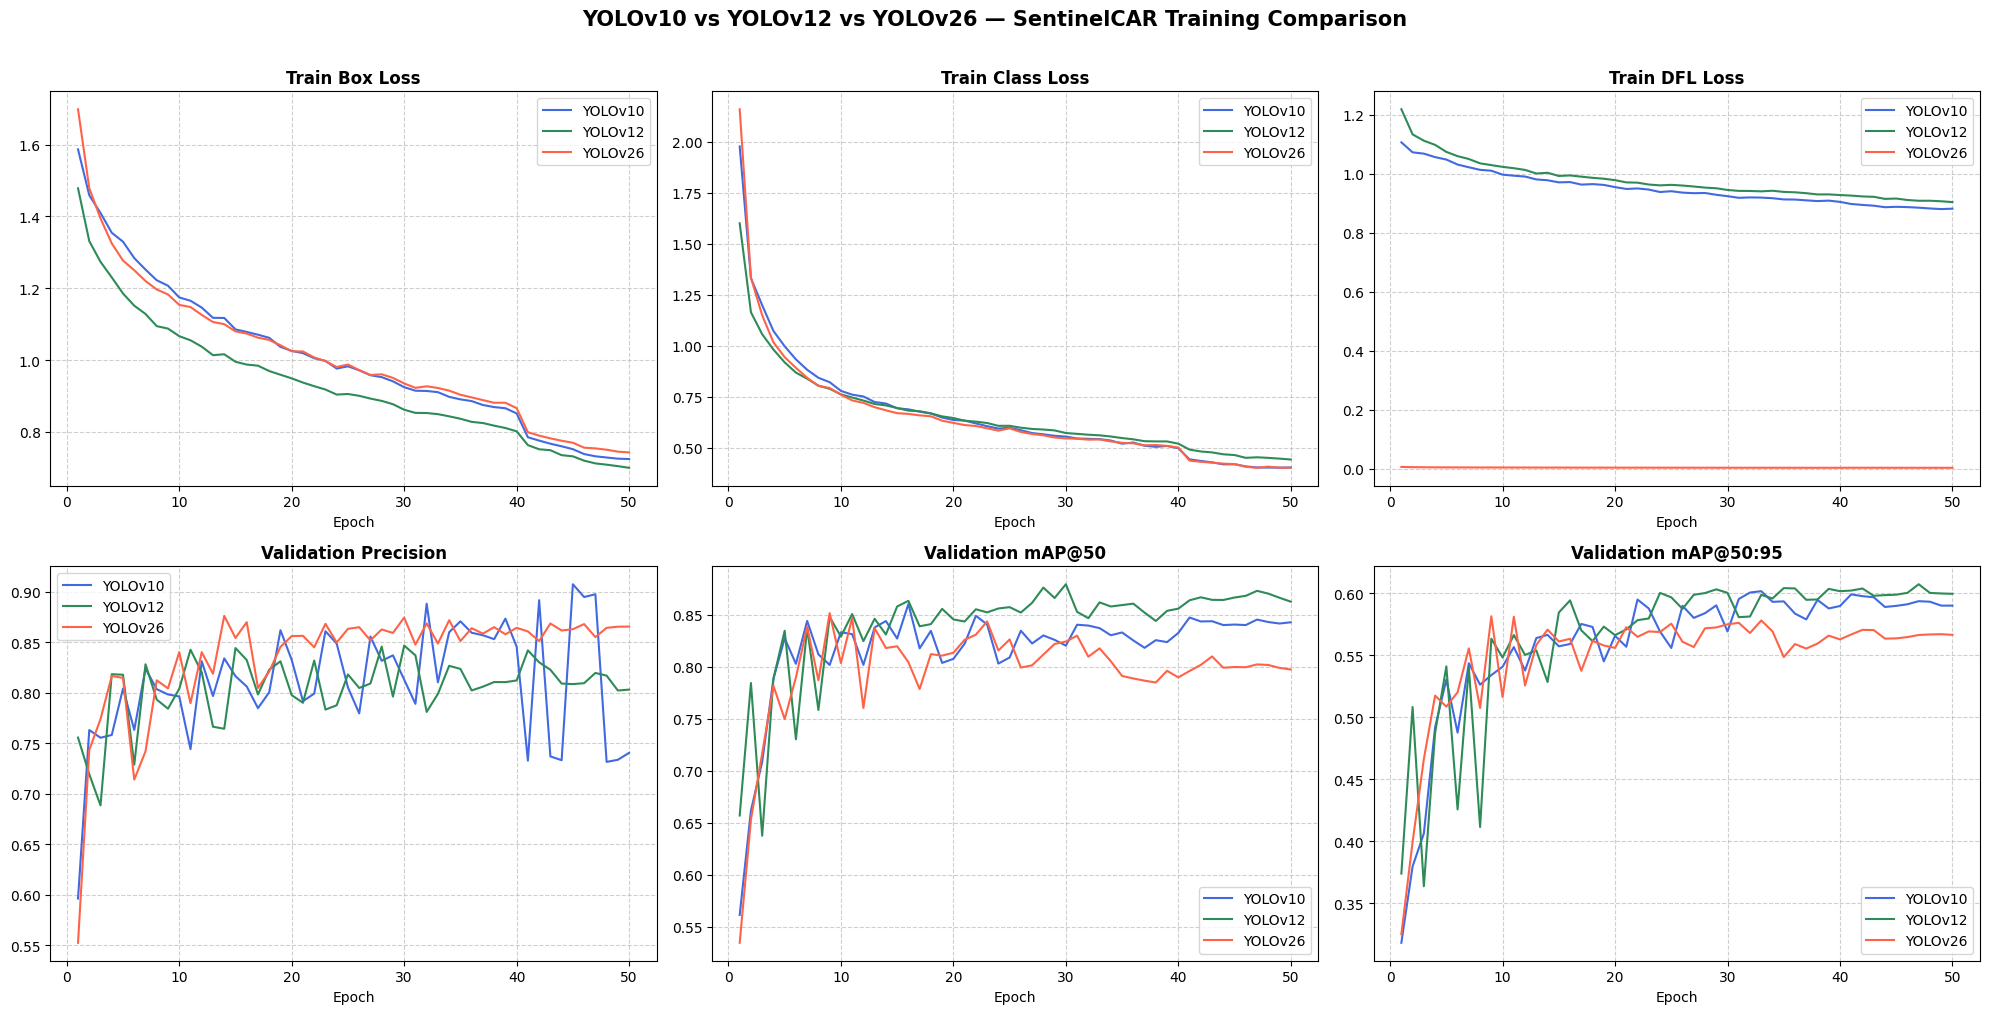

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import os

def load_results(path):
    if os.path.exists(path):
        df = pd.read_csv(path)
        df.columns = df.columns.str.strip()  # Safety strip
        return df
    return None

# Load all three results CSVs
y10_df = load_results('/kaggle/input/datasets/mdnahidulislam01/yolov10-sentinelcar/results.csv')
y12_df = load_results('/kaggle/working/runs/detect/SentinelCAR_YOLO/yolov12_sentinelcar/results.csv')
y26_df = load_results('/kaggle/working/runs/detect/SentinelCAR_YOLO/yolov26_sentinelcar/results.csv')

print(y10_df)

fig, axs = plt.subplots(2, 3, figsize=(20, 10))

colors = {'YOLOv10': 'royalblue', 'YOLOv12': 'seagreen', 'YOLOv26': 'tomato'}
dfs    = {'YOLOv10': y10_df,      'YOLOv12': y12_df,      'YOLOv26': y26_df}

# ── Row 1: Training Losses ──────────────────────────────────────────────
for name, df in dfs.items():
    if df is not None:
        axs[0,0].plot(df['epoch'], df['train/box_loss'],  label=name, color=colors[name])
        axs[0,1].plot(df['epoch'], df['train/cls_loss'],  label=name, color=colors[name])
        axs[0,2].plot(df['epoch'], df['train/dfl_loss'],  label=name, color=colors[name])

axs[0,0].set_title('Train Box Loss',      fontweight='bold')
axs[0,1].set_title('Train Class Loss',    fontweight='bold')
axs[0,2].set_title('Train DFL Loss',      fontweight='bold')

# ── Row 2: Validation Metrics ───────────────────────────────────────────
for name, df in dfs.items():
    if df is not None:
        axs[1,0].plot(df['epoch'], df['metrics/precision(B)'],  label=name, color=colors[name])
        axs[1,1].plot(df['epoch'], df['metrics/mAP50(B)'],      label=name, color=colors[name])
        axs[1,2].plot(df['epoch'], df['metrics/mAP50-95(B)'],   label=name, color=colors[name])

axs[1,0].set_title('Validation Precision',   fontweight='bold')
axs[1,1].set_title('Validation mAP@50',      fontweight='bold')
axs[1,2].set_title('Validation mAP@50:95',   fontweight='bold')

# ── Shared Formatting ────────────────────────────────────────────────────
for row in axs:
    for ax in row:
        ax.set_xlabel('Epoch')
        ax.legend()
        ax.grid(True, linestyle='--', alpha=0.6)

plt.suptitle('YOLOv10 vs YOLOv12 vs YOLOv26 — SentinelCAR Training Comparison',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 7. WEIGHT PRESERVATION
We record the path to the best weight files to ensure they can be loaded for evaluation in Notebook 4.


In [13]:
print('Best Saved Checkpoints:')
y10_best = os.path.abspath('/kaggle/input/datasets/mdnahidulislam01/yolov10-sentinelcar/weights/best.pt')
y12_best = os.path.abspath('/kaggle/working/runs/detect/SentinelCAR_YOLO/yolov12_sentinelcar/weights/best.pt')
y26_best = os.path.abspath('/kaggle/working/runs/detect/SentinelCAR_YOLO/yolov26_sentinelcar/weights/best.pt')

print(f'  YOLOv10 Best Weights: {y10_best}')
print(f'  YOLOv12 Best Weights: {y12_best}')
print(f'  YOLOv26 Best Weights: {y26_best}')


Best Saved Checkpoints:
  YOLOv10 Best Weights: /kaggle/input/datasets/mdnahidulislam01/yolov10-sentinelcar/weights/best.pt
  YOLOv12 Best Weights: /kaggle/working/runs/detect/SentinelCAR_YOLO/yolov12_sentinelcar/weights/best.pt
  YOLOv26 Best Weights: /kaggle/working/runs/detect/SentinelCAR_YOLO/yolov26_sentinelcar/weights/best.pt


## 8. SUMMARY TABLE
Here, we compile configuration parameters and final validation performance metrics for the three models.


In [16]:
summary_data = {
    'Model': ['YOLOv10 Nano', 'YOLOv12 Nano', 'YOLOv26 Nano'],
    'Parameters': ['2.3 M', '2.6 M', '2.1 M'],
    'Epochs Trained': [EPOCHS, EPOCHS, EPOCHS],
    'mAP@50 (Best Val)': [
        y10_df['metrics/mAP50(B)'].max() if y10_df is not None else 'N/A',
        y12_df['metrics/mAP50(B)'].max() if y12_df is not None else 'N/A',
        y26_df['metrics/mAP50(B)'].max() if y26_df is not None else 'N/A'
    ],
    'mAP@50:95 (Best Val)': [
        y10_df['metrics/mAP50-95(B)'].max() if y10_df is not None else 'N/A',
        y12_df['metrics/mAP50-95(B)'].max() if y12_df is not None else 'N/A',
        y26_df['metrics/mAP50-95(B)'].max() if y26_df is not None else 'N/A'
    ]
}

summary_df = pd.DataFrame(summary_data)
import IPython.display as display
display.display(summary_df)


,Model,Parameters,Epochs Trained,mAP@50 (Best Val),mAP@50:95 (Best Val)
0,YOLOv10 Nano,2.3 M,50,0.86047,0.60154
1,YOLOv12 Nano,2.6 M,50,0.87950,0.60712
2,YOLOv26 Nano,2.1 M,50,0.85171,0.58130
